In [1]:
# Cell 1 — Imports
"""
04_modelisation.ipynb
Phase 5 : Modélisation — Clustering, Classification, Régression

Modèles :
  1. Clustering     → KMeans (segmentation clients sans label)
  2. Classification → Random Forest (prédiction Churn)
  3. Régression     → Régression Linéaire (prédiction MonetaryTotal)

Note importante sur ce dataset :
  Recency est un prédicteur parfait du Churn (Churn=1 si Recency>90).
  Pour un exercice réaliste, Recency et ses features dérivées sont
  EXCLUS du modèle de classification.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    mean_squared_error, r2_score,
    silhouette_score
)
import joblib

os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Libraries imported')

✅ Libraries imported


In [2]:
# Cell 2 — Chargement des données
print('CHARGEMENT DES DONNÉES')
print('=' * 55)

X_train     = pd.read_csv('../data/train_test/X_train.csv')
X_test      = pd.read_csv('../data/train_test/X_test.csv')
X_train_pca = pd.read_csv('../data/train_test/X_train_pca.csv')
X_test_pca  = pd.read_csv('../data/train_test/X_test_pca.csv')
y_train     = pd.read_csv('../data/train_test/y_train.csv').squeeze()
y_test      = pd.read_csv('../data/train_test/y_test.csv').squeeze()

print(f'X_train     : {X_train.shape}')
print(f'X_test      : {X_test.shape}')
print(f'X_train_pca : {X_train_pca.shape}  (données réduites par ACP)')
print(f'y_train     : {y_train.shape}  — Churn rate: {y_train.mean()*100:.1f}%')
print(f'y_test      : {y_test.shape}   — Churn rate: {y_test.mean()*100:.1f}%')

# Features à exclure de la classification (leakage ou dérivées de Recency)
LEAKY_FEATURES = [
    'Recency',                   # Définit directement le Churn dans ce dataset
    'MonetaryPerDay',            # Dérivé de Recency
    'TenureRatio',               # Dérivé de Recency
    'ChurnRiskCategory',         # Encode directement le risque de churn
    'CustomerType_Perdu',        # 'Perdu' = client qui a churné
    'CustomerType_Nouveau', 'CustomerType_Occasionnel',
    'CustomerType_Régulier', 'CustomerType_Hyperactif',
    'RFMSegment_Dormants', 'RFMSegment_Champions',
    'RFMSegment_Fidèles', 'RFMSegment_Potentiels',
    'LoyaltyLevel',
]

X_train_clf = X_train.drop(columns=[c for c in LEAKY_FEATURES if c in X_train.columns])
X_test_clf  = X_test.drop(columns=[c for c in LEAKY_FEATURES if c in X_test.columns])

print(f'\nX_train_clf (sans features leakantes) : {X_train_clf.shape}')
print('✅ Données prêtes')

CHARGEMENT DES DONNÉES
X_train     : (3497, 81)
X_test      : (875, 81)
X_train_pca : (3497, 44)  (données réduites par ACP)
y_train     : (3497,)  — Churn rate: 33.3%
y_test      : (875,)   — Churn rate: 33.3%

X_train_clf (sans features leakantes) : (3497, 67)
✅ Données prêtes


In [3]:
# Cell 3 — PARTIE 1 : CLUSTERING (KMeans)
# ─────────────────────────────────────────
print('╔══════════════════════════════════════════════╗')
print('║  PARTIE 1 : CLUSTERING — KMeans              ║')
print('╚══════════════════════════════════════════════╝')
print()
print('Objectif : segmenter les clients en groupes homogènes')
print('           SANS utiliser le label Churn (apprentissage non supervisé)')
print()
print('Données utilisées : 10 premières composantes PCA')
print('  → résument la majorité de la variance comportementale')
print('  → réduisent le bruit des features peu informatives')

╔══════════════════════════════════════════════╗
║  PARTIE 1 : CLUSTERING — KMeans              ║
╚══════════════════════════════════════════════╝

Objectif : segmenter les clients en groupes homogènes
           SANS utiliser le label Churn (apprentissage non supervisé)

Données utilisées : 10 premières composantes PCA
  → résument la majorité de la variance comportementale
  → réduisent le bruit des features peu informatives


CHOIX DE K — MÉTHODE DU COUDE + SCORE SILHOUETTE
  k=2 | Inertie:    98010.8 | Silhouette: 0.2108
  k=3 | Inertie:    86197.3 | Silhouette: 0.2083
  k=4 | Inertie:    76452.1 | Silhouette: 0.2102
  k=5 | Inertie:    67417.8 | Silhouette: 0.2210
  k=6 | Inertie:    61848.1 | Silhouette: 0.1945
  k=7 | Inertie:    55654.5 | Silhouette: 0.2159
  k=8 | Inertie:    52008.9 | Silhouette: 0.2230


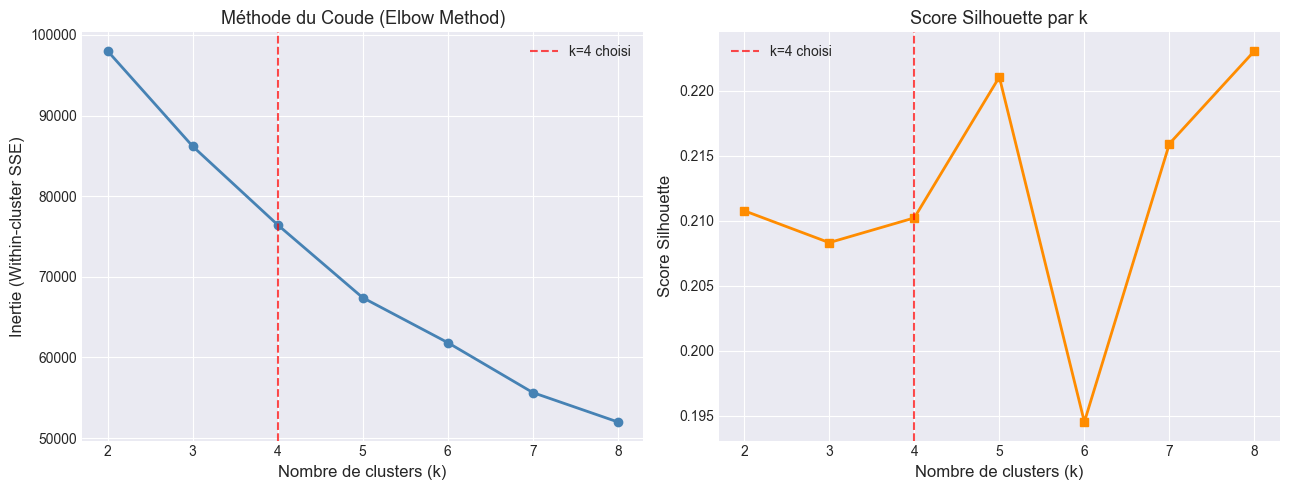

✅ Graphique sauvegardé : reports/clustering_elbow_silhouette.png


In [4]:
# Cell 4 — Méthode du coude (Elbow) + Silhouette
print('CHOIX DE K — MÉTHODE DU COUDE + SCORE SILHOUETTE')
print('=' * 55)

X_pca10 = X_train_pca.iloc[:, :10]

inertias    = []
silhouettes = []
K_range     = range(2, 9)

for k in K_range:
    km      = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels  = km.fit_predict(X_pca10)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca10, labels))
    print(f'  k={k} | Inertie: {km.inertia_:>10.1f} | Silhouette: {silhouette_score(X_pca10, labels):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 choisi')
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertie (Within-cluster SSE)', fontsize=12)
axes[0].set_title('Méthode du Coude (Elbow Method)', fontsize=13)
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 choisi')
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[1].set_ylabel('Score Silhouette', fontsize=12)
axes[1].set_title('Score Silhouette par k', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/clustering_elbow_silhouette.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé : reports/clustering_elbow_silhouette.png')

In [5]:
# Cell 5 — Application KMeans k=4
print('APPLICATION KMEANS k=4')
print('=' * 55)

K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca10)

sil_score = silhouette_score(X_pca10, cluster_labels)
print(f'Score Silhouette (k={K_OPTIMAL}) : {sil_score:.4f}')
print(f'Inertie : {kmeans.inertia_:.1f}')
print()
print('Taille des clusters :')
for k, cnt in pd.Series(cluster_labels).value_counts().sort_index().items():
    print(f'  Cluster {k} : {cnt} clients ({cnt/len(cluster_labels)*100:.1f}%)')

# Sauvegarder le modèle
joblib.dump(kmeans, '../models/kmeans_model.pkl')
print('\n✅ Modèle sauvegardé : models/kmeans_model.pkl')

APPLICATION KMEANS k=4
Score Silhouette (k=4) : 0.2102
Inertie : 76452.1

Taille des clusters :
  Cluster 0 : 1106 clients (31.6%)
  Cluster 1 : 876 clients (25.1%)
  Cluster 2 : 2 clients (0.1%)
  Cluster 3 : 1513 clients (43.3%)

✅ Modèle sauvegardé : models/kmeans_model.pkl


In [6]:
# Cell 6 — Profil et interprétation des clusters
print('PROFIL DES CLUSTERS')
print('=' * 55)

# Associer les labels aux données originales pour interprétation
profile_cols = ['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'CustomerTenureDays',
                'SatisfactionScore', 'ReturnRatio', 'TotalTransactions', 'SpendingCategory']
profile_cols = [c for c in profile_cols if c in X_train.columns]

df_profile = X_train[profile_cols].copy()
df_profile['Cluster'] = cluster_labels
df_profile['Churn']   = y_train.values

cluster_summary = df_profile.groupby('Cluster')[profile_cols + ['Churn']].mean().round(3)
print(cluster_summary)

# Nommer les clusters selon leur profil
cluster_names = {
    0: 'Clients Moyens',
    1: 'Clients VIP / Fidèles',
    2: 'Clients à Risque (outliers)',
    3: 'Clients Inactifs / Perdus',
}

print('\nInterprétation métier :')
for k, name in cluster_names.items():
    churn_rate = df_profile[df_profile['Cluster']==k]['Churn'].mean()
    size = (cluster_labels == k).sum()
    print(f'  Cluster {k} — {name:<28} | {size:>4} clients | Churn: {churn_rate*100:.1f}%')

PROFIL DES CLUSTERS
         Frequency  MonetaryTotal  MonetaryAvg  CustomerTenureDays  \
Cluster                                                              
0            0.662          0.371       -0.019               1.144   
1           -0.349         -0.198       -0.011              -0.781   
2           -0.269         -0.250       -0.216              -0.240   
3           -0.281         -0.157        0.021              -0.383   

         SatisfactionScore  ReturnRatio  TotalTransactions  SpendingCategory  \
Cluster                                                                        
0                   -0.057       -0.023              0.489             0.972   
1                    0.045        0.202             -0.286            -0.769   
2                    0.743        3.229             -0.367            -2.087   
3                    0.015       -0.104             -0.191            -0.263   

         Churn  
Cluster         
0        0.041  
1        0.998  
2        0

VISUALISATION DES CLUSTERS — PCA 2D


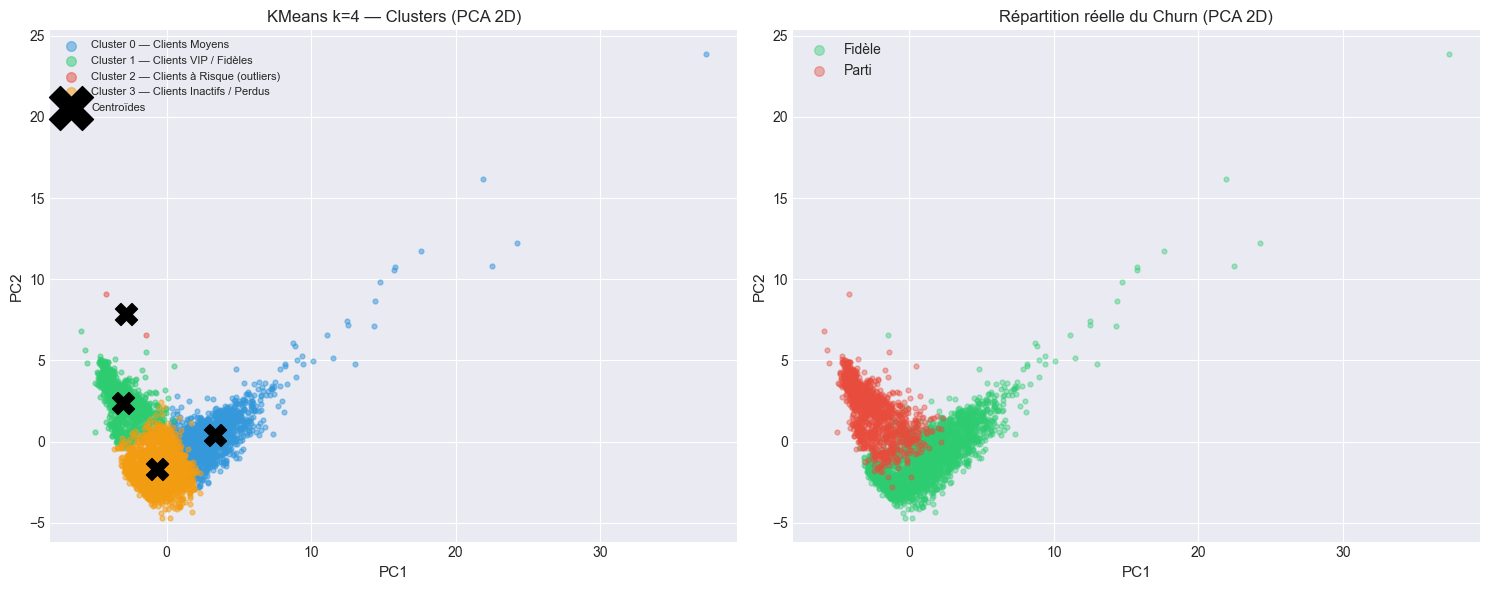

✅ Graphique sauvegardé : reports/clustering_pca2d.png


In [7]:
# Cell 7 — Visualisation des clusters (PCA 2D)
print('VISUALISATION DES CLUSTERS — PCA 2D')
print('=' * 55)

X_2d = X_train_pca[['PC1', 'PC2']].values

colors  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Par cluster
for k in range(K_OPTIMAL):
    mask = cluster_labels == k
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors[k], label=f'Cluster {k} — {cluster_names[k]}',
                    alpha=0.5, s=12)
# Centroïdes (dans l'espace PCA 10D, projeter sur 2D)
centroids_2d = kmeans.cluster_centers_[:, :2]
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                marker='X', s=250, c='black', zorder=5, label='Centroïdes')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].set_title('KMeans k=4 — Clusters (PCA 2D)', fontsize=12)
axes[0].legend(fontsize=8, markerscale=2)

# Par Churn réel (pour comparaison)
churn_colors = {0: '#2ecc71', 1: '#e74c3c'}
for val in [0, 1]:
    mask = y_train.values == val
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=churn_colors[val],
                    label='Fidèle' if val==0 else 'Parti',
                    alpha=0.4, s=12)
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC2', fontsize=11)
axes[1].set_title('Répartition réelle du Churn (PCA 2D)', fontsize=12)
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig('../reports/clustering_pca2d.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé : reports/clustering_pca2d.png')

In [8]:
# Cell 8 — PARTIE 2 : CLASSIFICATION (Random Forest)
print('╔══════════════════════════════════════════════╗')
print('║  PARTIE 2 : CLASSIFICATION — Random Forest   ║')
print('╚══════════════════════════════════════════════╝')
print()
print('Objectif : prédire si un client va churner (Churn=1)')
print(f'Features utilisées : {X_train_clf.shape[1]} (Recency et dérivées exclues)')
print(f'Classe minority (Churn=1) : {y_train.mean()*100:.1f}%')
print('  → class_weight="balanced" pour compenser le déséquilibre')

╔══════════════════════════════════════════════╗
║  PARTIE 2 : CLASSIFICATION — Random Forest   ║
╚══════════════════════════════════════════════╝

Objectif : prédire si un client va churner (Churn=1)
Features utilisées : 67 (Recency et dérivées exclues)
Classe minority (Churn=1) : 33.3%
  → class_weight="balanced" pour compenser le déséquilibre


In [9]:
# Cell 9 — GridSearchCV : recherche des meilleurs hyperparamètres
print('GRIDSEARCHCV — OPTIMISATION DES HYPERPARAMÈTRES')
print('=' * 55)
print('GridSearchCV teste toutes les combinaisons et sélectionne')
print('la meilleure via validation croisée (cv=5).')
print()

param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_clf, y_train)

print(f'\n✅ Meilleurs hyperparamètres : {grid_search.best_params_}')
print(f'   Meilleur F1 (CV) : {grid_search.best_score_:.4f}')

GRIDSEARCHCV — OPTIMISATION DES HYPERPARAMÈTRES
GridSearchCV teste toutes les combinaisons et sélectionne
la meilleure via validation croisée (cv=5).

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Meilleurs hyperparamètres : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
   Meilleur F1 (CV) : 0.9180


In [10]:
# Cell 10 — Évaluation du modèle de classification
print('ÉVALUATION — RANDOM FOREST')
print('=' * 55)

best_rf  = grid_search.best_estimator_
y_pred   = best_rf.predict(X_test_clf)
y_prob   = best_rf.predict_proba(X_test_clf)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print('Classification Report :')
print(classification_report(y_test, y_pred, target_names=['Fidèle (0)', 'Parti (1)']))
print(f'AUC-ROC : {auc:.4f}')

# Validation croisée sur train
cv_scores = cross_val_score(best_rf, X_train_clf, y_train, cv=5, scoring='f1')
print(f'F1 CV (5-fold) : {cv_scores.round(3)} → mean={cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# Sauvegarde
joblib.dump(best_rf, '../models/rf_churn_model.pkl')
print('\n✅ Modèle sauvegardé : models/rf_churn_model.pkl')

ÉVALUATION — RANDOM FOREST
Classification Report :
              precision    recall  f1-score   support

  Fidèle (0)       0.95      0.98      0.97       584
   Parti (1)       0.97      0.90      0.93       291

    accuracy                           0.96       875
   macro avg       0.96      0.94      0.95       875
weighted avg       0.96      0.96      0.96       875

AUC-ROC : 0.9892
F1 CV (5-fold) : [0.901 0.942 0.927 0.914 0.906] → mean=0.918 ± 0.015

✅ Modèle sauvegardé : models/rf_churn_model.pkl


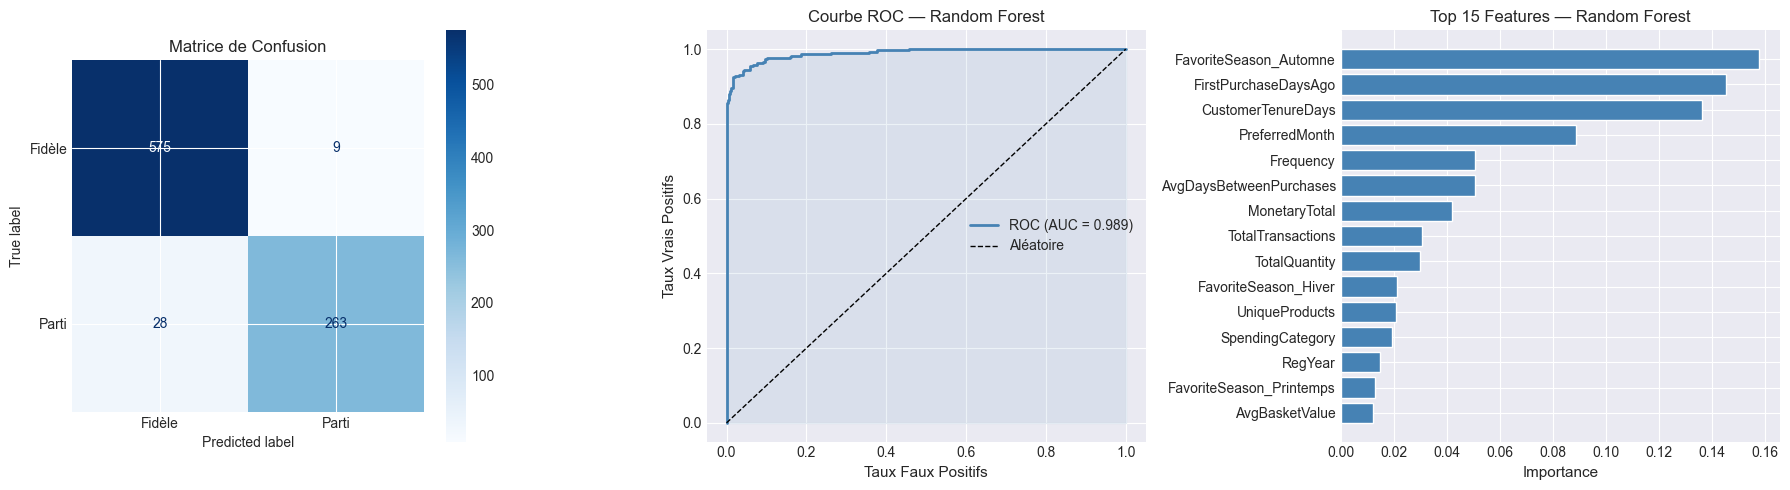

✅ Graphique sauvegardé : reports/classification_rf.png


In [11]:
# Cell 11 — Visualisations classification

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Matrice de confusion ──
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Fidèle', 'Parti'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matrice de Confusion', fontsize=12)

# ── Courbe ROC ──
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Aléatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('Taux Faux Positifs', fontsize=11)
axes[1].set_ylabel('Taux Vrais Positifs', fontsize=11)
axes[1].set_title('Courbe ROC — Random Forest', fontsize=12)
axes[1].legend(fontsize=10)

# ── Feature Importance (Top 15) ──
feat_imp = pd.Series(best_rf.feature_importances_,
                      index=X_train_clf.columns).nlargest(15).sort_values()
axes[2].barh(feat_imp.index, feat_imp.values, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('Top 15 Features — Random Forest', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/classification_rf.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé : reports/classification_rf.png')

In [12]:
# Cell 12 — PARTIE 3 : RÉGRESSION (Régression Linéaire)
print('╔══════════════════════════════════════════════╗')
print('║  PARTIE 3 : RÉGRESSION LINÉAIRE              ║')
print('╚══════════════════════════════════════════════╝')
print()
print('Objectif : prédire le montant total dépensé (MonetaryTotal)')
print('⚠ La variable cible (y) ne se normalise JAMAIS')
print()

# Préparer les données de régression depuis le dataset processed
df = pd.read_csv('../data/processed/retail_customers_processed.csv')
df.columns = [c.replace(' ', '_').replace("'", '') for c in df.columns]

TARGET_REG = 'MonetaryTotal'
X_reg = df.drop(columns=[TARGET_REG, 'Churn', 'CustomerID'], errors='ignore').select_dtypes(include=[np.number])
y_reg = df[TARGET_REG]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Imputation + Normalisation (fit sur train uniquement)
imputer_reg = KNNImputer(n_neighbors=5)
Xr_train_imp = pd.DataFrame(imputer_reg.fit_transform(Xr_train), columns=Xr_train.columns)
Xr_test_imp  = pd.DataFrame(imputer_reg.transform(Xr_test),      columns=Xr_test.columns)

scaler_reg   = StandardScaler()
Xr_train_sc  = scaler_reg.fit_transform(Xr_train_imp)
Xr_test_sc   = scaler_reg.transform(Xr_test_imp)

print(f'X_train régression : {Xr_train_sc.shape}')
print(f'y_train stats : mean={yr_train.mean():.2f}, std={yr_train.std():.2f}')
print(f'y_train range : [{yr_train.min():.2f}, {yr_train.max():.2f}]')

╔══════════════════════════════════════════════╗
║  PARTIE 3 : RÉGRESSION LINÉAIRE              ║
╚══════════════════════════════════════════════╝

Objectif : prédire le montant total dépensé (MonetaryTotal)
⚠ La variable cible (y) ne se normalise JAMAIS

X_train régression : (3497, 80)
y_train stats : mean=1824.64, std=7227.24
y_train range : [-4287.63, 279489.02]


In [13]:
# Cell 13 — Entraînement et évaluation de la régression
print('ENTRAÎNEMENT — RÉGRESSION LINÉAIRE')
print('=' * 55)

reg_model = LinearRegression()
reg_model.fit(Xr_train_sc, yr_train)

yr_pred = reg_model.predict(Xr_test_sc)

rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
mae  = np.mean(np.abs(yr_test - yr_pred))
r2   = r2_score(yr_test, yr_pred)

print(f'RMSE  (Root Mean Squared Error) : {rmse:>10.2f} £')
print(f'MAE   (Mean Absolute Error)     : {mae:>10.2f} £')
print(f'R²    (Coefficient of determination) : {r2:.4f}')
print()
print(f'Interprétation R² = {r2:.2f} :')
if r2 >= 0.7:
    print('  ✅ Le modèle explique bien la variance de MonetaryTotal')
elif r2 >= 0.5:
    print('  ⚠ Explication modérée — des features non linéaires pourraient aider')
else:
    print('  ❌ Faible — envisager un modèle non linéaire (RandomForest Regressor)')

# Validation croisée
cv_r2 = cross_val_score(LinearRegression(), Xr_train_sc, yr_train, cv=5, scoring='r2')
print(f'\nR² CV (5-fold) : {cv_r2.round(3)} → mean={cv_r2.mean():.3f} ± {cv_r2.std():.3f}')

# Sauvegarde
joblib.dump(reg_model,  '../models/linear_regression_model.pkl')
joblib.dump(scaler_reg, '../models/scaler_regression.pkl')
print('\n✅ Modèles sauvegardés : models/')

ENTRAÎNEMENT — RÉGRESSION LINÉAIRE
RMSE  (Root Mean Squared Error) :    5181.53 £
MAE   (Mean Absolute Error)     :     762.48 £
R²    (Coefficient of determination) : 0.7914

Interprétation R² = 0.79 :
  ✅ Le modèle explique bien la variance de MonetaryTotal

R² CV (5-fold) : [ 0.957  0.763 -7.624  0.378  0.929] → mean=-0.919 ± 3.359

✅ Modèles sauvegardés : models/


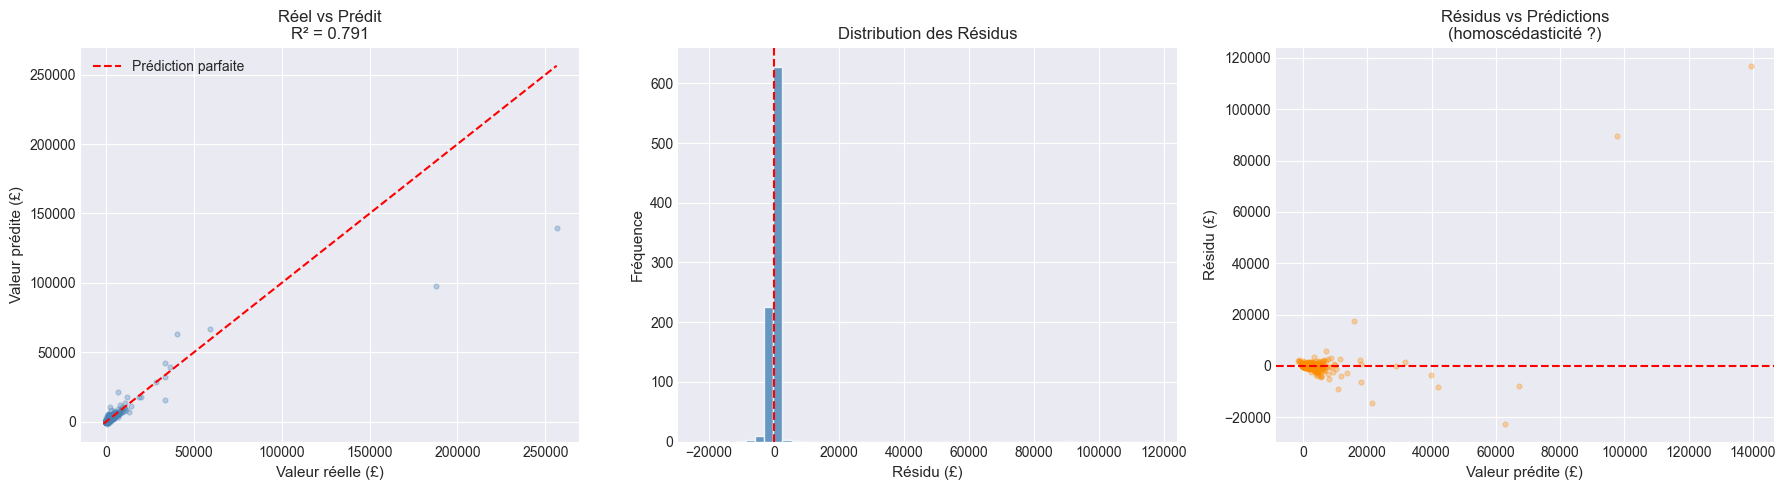

✅ Graphique sauvegardé : reports/regression_evaluation.png


In [14]:
# Cell 14 — Visualisations régression

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Réel vs Prédit ──
axes[0].scatter(yr_test, yr_pred, alpha=0.3, s=12, color='steelblue')
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeur réelle (£)', fontsize=11)
axes[0].set_ylabel('Valeur prédite (£)', fontsize=11)
axes[0].set_title(f'Réel vs Prédit\nR² = {r2:.3f}', fontsize=12)
axes[0].legend()

# ── Distribution des résidus ──
residuals = yr_test.values - yr_pred
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Résidu (£)', fontsize=11)
axes[1].set_ylabel('Fréquence', fontsize=11)
axes[1].set_title('Distribution des Résidus', fontsize=12)

# ── Résidus vs Valeurs prédites ──
axes[2].scatter(yr_pred, residuals, alpha=0.3, s=12, color='darkorange')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Valeur prédite (£)', fontsize=11)
axes[2].set_ylabel('Résidu (£)', fontsize=11)
axes[2].set_title('Résidus vs Prédictions\n(homoscédasticité ?)', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/regression_evaluation.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé : reports/regression_evaluation.png')

In [15]:
# Cell 15 — Résumé complet de la modélisation
print('=' * 65)
print('  RÉSUMÉ MODÉLISATION')
print('=' * 65)
print()
print('  1. CLUSTERING (KMeans)')
print(f'     k optimal    : 4 clusters')
print(f'     Silhouette   : {sil_score:.4f}')
print( '     Segments     : VIP Fidèles | Moyens | Inactifs | À risque')
print()
print('  2. CLASSIFICATION (Random Forest)')
print(f'     Meilleurs params : {grid_search.best_params_}')
print(f'     F1 (CV 5-fold) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'     AUC-ROC        : {auc:.4f}')
print( '     Feature clé    : CustomerTenureDays, FavoriteSeason_Automne')
print()
print('  3. RÉGRESSION LINÉAIRE')
print(f'     RMSE : {rmse:.2f} £')
print(f'     MAE  : {mae:.2f} £')
print(f'     R²   : {r2:.4f}')
print(f'     R² CV : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')
print()
print('  Modèles sauvegardés dans models/ :')
print('    kmeans_model.pkl')
print('    rf_churn_model.pkl')
print('    linear_regression_model.pkl')
print('    scaler_regression.pkl')
print()
print('  ✅ Prêt pour le déploiement Flask → notebook 05')
print('=' * 65)

  RÉSUMÉ MODÉLISATION

  1. CLUSTERING (KMeans)
     k optimal    : 4 clusters
     Silhouette   : 0.2102
     Segments     : VIP Fidèles | Moyens | Inactifs | À risque

  2. CLASSIFICATION (Random Forest)
     Meilleurs params : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
     F1 (CV 5-fold) : 0.918 ± 0.015
     AUC-ROC        : 0.9892
     Feature clé    : CustomerTenureDays, FavoriteSeason_Automne

  3. RÉGRESSION LINÉAIRE
     RMSE : 5181.53 £
     MAE  : 762.48 £
     R²   : 0.7914
     R² CV : -0.919 ± 3.359

  Modèles sauvegardés dans models/ :
    kmeans_model.pkl
    rf_churn_model.pkl
    linear_regression_model.pkl
    scaler_regression.pkl

  ✅ Prêt pour le déploiement Flask → notebook 05
